# 03 — Manual Validation Sampling: wondr by BNI

**Tujuan:** Validasi rating filter (rating 1–2) sebagai proxy keluhan teknis.

**Metodologi:**
- Sampling: equal-allocation stratified by `relative_month` (25 × 12 = 300)
- Estimator: weighted proportion (Cochran, 1977)
- Klasifikasi: 5 kategori (4 dari Maalej et al., 2016 + 1 ekstensi domain banking)
- Threshold validitas: >70% kategori teknis (Bug Report + Feature Request + User Experience)

**Output:** `data/validation/wondr_validation_sample.csv` siap upload ke Google Sheets untuk labeling manual.

**Referensi:**
- Maalej, W., Kurtanović, Z., Nabil, H., & Stanik, C. (2016). On the automatic classification of app reviews. *Requirements Engineering*, 21(3), 311–331.
- Cochran, W.G. (1977). *Sampling Techniques*, 3rd ed. Wiley.

In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path

# Add project root to sys.path so we can import from utils/
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from utils.validation import (
    stratified_sample_by_month,
    prepare_for_sheets,
    ALL_CATEGORIES,
    TECHNICAL_CATEGORIES,
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

print(f"pandas version: {pd.__version__}")
print(f"numpy version:  {np.__version__}")
print(f"Project root:   {project_root}")
print(f"Categories:     {ALL_CATEGORIES}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
pandas version: 3.0.2
numpy version:  2.4.4
Project root:   C:\Users\Rabithah Zahiratus S\TA
Categories:     ['Bug Report', 'Feature Request', 'User Experience', 'Rating (Praise/Dispraise)', 'Non-Technical Complaint']


## 1. Load Data wondr

Load output dari preprocessing pipeline (`wondr_bertopic.csv`). Ini sudah:
- Difilter rating 1–2 (proxy keluhan)
- Memiliki kolom `relative_month` (1–12 dari launch wondr: 5 Juli 2024 – 4 Juli 2025)
- Sudah di-preprocess (text cleaning, normalization)

In [4]:
# Load wondr filtered data
DATA_PATH = project_root / "data" / "processed" / "wondr_bertopic.csv"
df_wondr = pd.read_csv(DATA_PATH)

print(f"Shape: {df_wondr.shape}")
print(f"Columns: {list(df_wondr.columns)}")
print(f"\nDtypes:")
print(df_wondr.dtypes)
print(f"\nFirst 3 rows:")
df_wondr.head(3)

Shape: (8982, 6)
Columns: ['review_id', 'review_text_cleaned', 'relative_month', 'relative_week', 'date_wib', 'rating']

Dtypes:
review_id                str
review_text_cleaned      str
relative_month         int64
relative_week          int64
date_wib                 str
rating                 int64
dtype: object

First 3 rows:


,review_id,review_text_cleaned,relative_month,relative_week,date_wib,rating
0,05c4afd9-2b73-462f-93ed-ad2f853647b5,kok tidak bisa di screenshot bagaimana caranya kasih bukti ke penerima bagaimana sih ini aplikasi,1,1,2024-07-05 16:24:39,2
1,e4786af6-59c9-4f34-897f-d20f8c5f412b,mau daftar susah disuruh telpon bni tapi tidak bisa dihubungi aneh,1,1,2024-07-05 16:28:04,1
2,cc78e674-330f-46f1-b279-27a9cbe2d823,tidak bisa buka rekening padahal no hp sudah sesuai customer service tidak membantu,1,1,2024-07-05 21:14:52,1


## 2. Verifikasi Distribusi Populasi per Relative Month

Sebelum sampling, cek distribusi populasi:
- Pastikan setiap bulan (1–12) punya cukup data (minimum 25 untuk equal stratified n=25)
- Identify bulan yang dominan vs minoritas (untuk konteks weighted estimator nanti)

Total populasi (rating 1-2): 8,982
Jumlah strata (relative_month): 12
Min populasi per bulan: 302 (bulan 1)
Max populasi per bulan: 2568 (bulan 5)

Distribusi lengkap:
                count    pct
relative_month              
1                 302   3.36
2                 395   4.40
3                 544   6.06
4                 678   7.55
5                2568  28.59
6                1297  14.44
7                 727   8.09
8                 621   6.91
9                 462   5.14
10                357   3.97
11                388   4.32
12                643   7.16

✅ Semua bulan punya ≥25 data. Sampling tanpa replacement feasible.


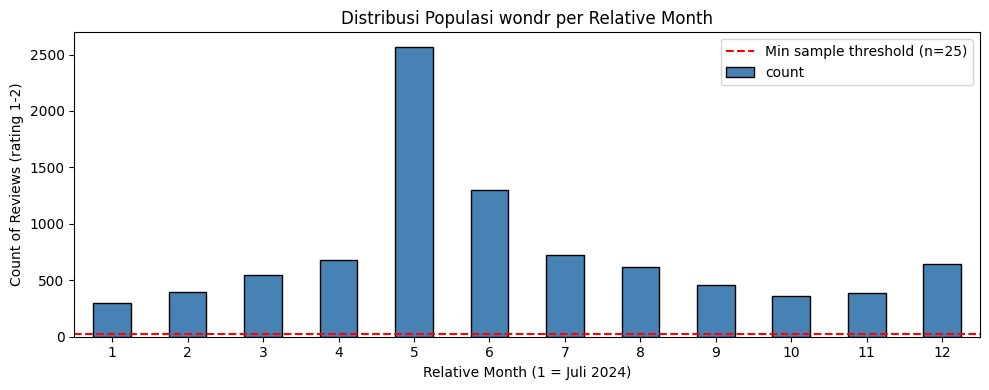

In [5]:
# Distribusi populasi per relative_month
pop_dist = df_wondr.groupby("relative_month").size().rename("count")
pop_pct = (pop_dist / pop_dist.sum() * 100).round(2).rename("pct")
pop_summary = pd.concat([pop_dist, pop_pct], axis=1)

print(f"Total populasi (rating 1-2): {len(df_wondr):,}")
print(f"Jumlah strata (relative_month): {df_wondr['relative_month'].nunique()}")
print(f"Min populasi per bulan: {pop_dist.min()} (bulan {pop_dist.idxmin()})")
print(f"Max populasi per bulan: {pop_dist.max()} (bulan {pop_dist.idxmax()})")
print(f"\nDistribusi lengkap:")
print(pop_summary.to_string())

# Pre-flight check: cukup data untuk n=25 per stratum?
N_PER_STRATUM = 25
insufficient = pop_dist[pop_dist < N_PER_STRATUM]
if len(insufficient) > 0:
    print(f"\n⚠️ WARNING: Bulan berikut punya <{N_PER_STRATUM} data, tidak bisa di-sample tanpa replacement:")
    print(insufficient.to_string())
else:
    print(f"\n✅ Semua bulan punya ≥{N_PER_STRATUM} data. Sampling tanpa replacement feasible.")

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 4))
pop_dist.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.axhline(y=N_PER_STRATUM, color="red", linestyle="--", label=f"Min sample threshold (n={N_PER_STRATUM})")
ax.set_xlabel("Relative Month (1 = Juli 2024)")
ax.set_ylabel("Count of Reviews (rating 1-2)")
ax.set_title("Distribusi Populasi wondr per Relative Month")
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Test Sampling Function (Sample Kecil)

Sebelum generate full sample 300, test dulu dengan `n_per_stratum=2` (= 24 sample total) untuk:
- Verify function jalan tanpa error
- Confirm output shape & shuffling behavior
- Inspect contoh row biar tau apa yang akan kita label nanti

**Working convention:** Test small first, scale up after.

In [6]:
# Test dengan sample kecil dulu (2 per bulan = 24 sample)
test_sample = stratified_sample_by_month(
    df_wondr,
    n_per_stratum=2,
    random_state=42,
)

print(f"Test sample shape: {test_sample.shape}")
print(f"Distribusi per bulan:")
print(test_sample.groupby("relative_month").size().to_string())
print(f"\nBulan urutan first 10 rows (verify shuffled, bukan urut M1-M12):")
print(test_sample["relative_month"].head(10).tolist())
print(f"\nNo duplicates: {test_sample['review_id'].is_unique}")
print(f"\nFirst 5 rows (preview):")
test_sample.head(5)

Test sample shape: (24, 6)
Distribusi per bulan:
relative_month
1     2
2     2
3     2
4     2
5     2
6     2
7     2
8     2
9     2
10    2
11    2
12    2

Bulan urutan first 10 rows (verify shuffled, bukan urut M1-M12):
[5, 9, 1, 10, 6, 5, 7, 1, 11, 3]

No duplicates: True

First 5 rows (preview):


,review_id,review_text_cleaned,relative_month,relative_week,date_wib,rating
0,b50d16c1-02a1-4f38-a4e8-1758dbab6785,transaksi gagal tapi saldo terpotong beli pulsa listrik sejuta statusnya gagal saldo terpotong dengan harapan dana di refund karena memang status ...,5,22,2024-12-02 17:10:09,1
1,c2379fa5-e544-4fdb-8be8-6da36f832e4d,mohon bantuannya transaksi saya gagal dan saldo terpotong,9,37,2025-03-19 10:06:52,2
2,0c2ec068-73d7-4e08-9057-2ff58a4cd4dc,ini aplikasi susah amat sih verifikasi wajah terutama pada saat mengedipkan matanya tambah lagi waktunya singkat banget niat apa tidak sih bikin a...,1,3,2024-07-25 04:38:09,1
3,c64c45c8-e1ca-4b54-ae72-9d7efa7751c7,nyesal download wondr transaksi gagal tabungan tetap terpotong mending pakai mobile bangking,10,43,2025-04-26 03:49:09,1
4,725d263d-2303-4ce1-aaf3-53e8eda6b04d,baru daftar eh loading lama tidak bisa dibuka munculnya saya setuju terus enakan bni banking yang dulu dan sering banyak komplen saat qris gagal t...,6,23,2024-12-09 16:55:12,1


## 4. Generate Full Sample (n=25 per Bulan, 300 Total)

Setelah test pass, generate sample finali untuk labeling.
- `n_per_stratum=25` × 12 bulan = **300 sample**
- `random_state=42` untuk reproducibility
- Shuffled untuk hindari calibration drift saat manual labeling

In [7]:
# Generate sample final
sample_wondr = stratified_sample_by_month(
    df_wondr,
    n_per_stratum=25,
    random_state=42,
)

print(f"Full sample shape: {sample_wondr.shape}")
print(f"Distribusi per bulan:")
print(sample_wondr.groupby("relative_month").size().to_string())
print(f"\nFirst 10 months in shuffled order:")
print(sample_wondr["relative_month"].head(10).tolist())
print(f"\nDistribusi rating dalam sample:")
print(sample_wondr["rating"].value_counts().to_string())

Full sample shape: (300, 6)
Distribusi per bulan:
relative_month
1     25
2     25
3     25
4     25
5     25
6     25
7     25
8     25
9     25
10    25
11    25
12    25

First 10 months in shuffled order:
[9, 11, 7, 1, 10, 10, 8, 5, 1, 8]

Distribusi rating dalam sample:
rating
1    239
2     61


In [8]:
# Comprehensive sanity checks sebelum save
assert sample_wondr.shape[0] == 300, f"Expected 300 rows, got {sample_wondr.shape[0]}"
assert sample_wondr["review_id"].is_unique, "Duplicate review_ids detected!"
assert sample_wondr["rating"].isin([1, 2]).all(), "Rating outside [1, 2] detected!"
assert sample_wondr.groupby("relative_month").size().eq(25).all(), "Stratum size != 25 detected!"
assert sample_wondr["review_text_cleaned"].notna().all(), "Missing review text detected!"

print("✅ All sanity checks passed:")
print(f"   - Shape: 300 rows ✓")
print(f"   - All review_ids unique ✓")
print(f"   - All ratings in [1, 2] ✓")
print(f"   - All strata have exactly 25 samples ✓")
print(f"   - No missing review text ✓")

# Statistical summary
print(f"\nReview text length statistics (chars):")
text_len = sample_wondr["review_text_cleaned"].str.len()
print(text_len.describe().to_string())

✅ All sanity checks passed:
   - Shape: 300 rows ✓
   - All review_ids unique ✓
   - All ratings in [1, 2] ✓
   - All strata have exactly 25 samples ✓
   - No missing review text ✓

Review text length statistics (chars):
count    300.000000
mean     134.313333
std       98.394241
min       23.000000
25%       65.000000
50%      109.000000
75%      170.750000
max      547.000000


## 5. Prepare for Sheets & Save CSV

Format sample untuk upload Google Sheets:
- Reorder kolom: labeler-facing first (`relative_month`, `rating`, `review_text_cleaned`)
- Append 2 kolom kosong: `category` (untuk dropdown) dan `notes` (untuk edge case)
- Save ke `data/validation/wondr_validation_sample.csv`

**Note:** Folder `data/validation/` di-gitignore (sama seperti `data/processed/`). 
Hasil labeling nanti harus di-backup manual ke Google Drive.

In [9]:
# Prepare format untuk Sheets
# Note: text_col override karena kolom kita 'review_text_cleaned' bukan default 'review_text'
sheets_ready = prepare_for_sheets(
    sample_wondr,
    text_col="review_text_cleaned",
)

print(f"Shape: {sheets_ready.shape}")
print(f"Column order: {list(sheets_ready.columns)}")
print(f"\nFirst 3 rows preview:")
sheets_ready.head(3)

Shape: (300, 8)
Column order: ['relative_month', 'rating', 'review_text_cleaned', 'category', 'notes', 'review_id', 'relative_week', 'date_wib']

First 3 rows preview:


,relative_month,rating,review_text_cleaned,category,notes,review_id,relative_week,date_wib
0,9,2,kenapa ya sekarang kalo mau kirim uang sering gagl qris juga begitu wallet juga gagal bagaimana sih ini,,,8e3bf340-2fde-4b37-a21c-f1e796aa7dcb,37,2025-03-19 06:45:03
1,11,1,saldo lebih dari jumlah yang ditf tapi dibilang saldo tidak cukup,,,64229e8b-f608-4886-8a26-a66a25c09f20,44,2025-05-06 08:31:20
2,7,1,aku baru bikin tapi bisa di buka,,,7576a63c-2198-4373-a578-8f5e903293c2,29,2025-01-22 04:12:11


In [10]:
# Save ke data/validation/wondr_validation_sample.csv
OUTPUT_DIR = project_root / "data" / "validation"
OUTPUT_DIR.mkdir(exist_ok=True)  # Defensive: create folder kalau belum ada
OUTPUT_PATH = OUTPUT_DIR / "wondr_validation_sample.csv"

sheets_ready.to_csv(
    OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig",  # BOM for Google Sheets/Excel UTF-8 compatibility
)

# Verify file ditulis benar
import os
file_size_kb = os.path.getsize(OUTPUT_PATH) / 1024
print(f"✅ File saved: {OUTPUT_PATH}")
print(f"   Size: {file_size_kb:.1f} KB")
print(f"   Rows: {len(sheets_ready)} + 1 header")

# Re-load untuk verify integritas
df_check = pd.read_csv(OUTPUT_PATH)
print(f"\nReload check:")
print(f"   Shape: {df_check.shape}")
print(f"   Columns: {list(df_check.columns)}")
print(f"   category empty: {df_check['category'].isna().all()}")
print(f"   notes empty: {df_check['notes'].isna().all()}")

✅ File saved: C:\Users\Rabithah Zahiratus S\TA\data\validation\wondr_validation_sample.csv
   Size: 59.4 KB
   Rows: 300 + 1 header

Reload check:
   Shape: (300, 8)
   Columns: ['relative_month', 'rating', 'review_text_cleaned', 'category', 'notes', 'review_id', 'relative_week', 'date_wib']
   category empty: True
   notes empty: True
